# Unsupervised Grouping and Gating Quality Evaluation for derived_8.2

This notebook explores alternative ways of grouping the observations in the `derived_8.2` soil moisture dataset using only features available at inference time (without relying on the target variable or training a router). We evaluate:
- **Univariate proxy binning** (SMAP, API, LST, NDMI)
- **Seasonal/month-based groupings**
- **Static feature groupings**
- **Multivariate K-Means clustering** (dynamic, hybrid, full V3)

Each grouping is evaluated for both $K=2$ (binary) and $K=3$ (3-class) regimes. We measure gating quality using target separability, cluster balance, and feature relationship divergence (how much feature correlations with target differ across clusters).


In [1]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ks_2samp
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Set style for premium aesthetics using standard matplotlib
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 14,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'figure.titlesize': 16,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'axes.grid': True,
    'grid.alpha': 0.3,
    'grid.linestyle': '--'
})

print("Libraries imported successfully and plot settings initialized.")


Libraries imported successfully and plot settings initialized.


## 1. Load and Clean Dataset

We load `train.csv` and `val.csv` and merge them with `station_static_features.csv`. We also extract date properties like month and season, and import the `OVERALL_SELECTED_FEATURES_V3` list to restrict our analysis to the active feature set.

In [2]:
# Define paths
TRAIN_PATH = "../../../data/splits/derived_8.2/train.csv"
VAL_PATH = "../../../data/splits/derived_8.2/val.csv"
STATIC_PATH = "../../../data/splits/derived_8.2/station_static_features.csv"

# Load datasets
train_df = pd.read_csv(TRAIN_PATH)
val_df = pd.read_csv(VAL_PATH)
static_df = pd.read_csv(STATIC_PATH)

# Add month and season features to train and val
def add_date_features(df):
    df = df.copy()
    df['date'] = pd.to_datetime(df['date'])
    df['month'] = df['date'].dt.month
    
    # Season mapping
    # Dry: July, August, September (7, 8, 9)
    # Wet: November, December, January, February, March (11, 12, 1, 2, 3)
    # Transition: April, May, June, October (4, 5, 6, 10)
    conditions = [
        df['month'].isin([7, 8, 9]),
        df['month'].isin([11, 12, 1, 2, 3]),
        df['month'].isin([4, 5, 6, 10])
    ]
    choices = ['Dry_Season', 'Wet_Season', 'Transition_Season']
    df['season'] = np.select(conditions, choices, default='Transition_Season')
    return df

train_df = add_date_features(train_df)
val_df = add_date_features(val_df)

# Merge static features based on station_id if not already merged
static_cols_to_merge = [c for c in static_df.columns if c not in train_df.columns or c == 'station_id']
if len(static_cols_to_merge) > 1:
    train_df = train_df.merge(static_df[static_cols_to_merge], on='station_id', how='left')
    val_df = val_df.merge(static_df[static_cols_to_merge], on='station_id', how='left')

# Import V3 feature set
splits_dir = os.path.abspath(os.path.join(os.getcwd(), '..', '..', '..', 'data', 'splits', 'derived_8.2'))
if splits_dir not in sys.path:
    sys.path.append(splits_dir)
from dataset_metadata import OVERALL_SELECTED_FEATURES_V3

print(f"Loaded train: {train_df.shape} and val: {val_df.shape}")
print(f"Static features merged. Selected V3 feature set size: {len(OVERALL_SELECTED_FEATURES_V3)}")

Loaded train: (15704, 502) and val: (7149, 502)
Static features merged. Selected V3 feature set size: 47


## 2. Gating Quality Evaluation Framework

We define helper functions to quantitatively evaluate any grouping method. The metrics include:
1. **Target Separability**:
   - **Kolmogorov-Smirnov (KS) Statistics**: Pairwise KS test statistics of target soil moisture between the groups. Higher KS indicates more distinct target distributions.
   - **Variance Reduction (VR)**: The percentage of target variance explained by the grouping.
2. **Feature Relationship Divergence**:
   - For a set of features, we calculate their correlation with the target variable within each group.
   - For each feature, we compute the standard deviation of its correlation across the groups.
   - **Divergence Index (D_V3)**: The average correlation standard deviation across all V3 features.
   - **Divergence Index (D_Top20)**: The average correlation standard deviation across the top 20 globally correlated V3 features.
   - **Max Correlation Drift**: The maximum difference in correlation for a single feature between any two groups.
3. **Group Balance (Entropy)**:
   - Normalized Shannon entropy of the group sizes (ranges from 0 to 1, where 1 is perfectly balanced).

In [3]:
from scipy.stats import ks_2samp

def compute_entropy(labels):
    """Computes normalized Shannon entropy of cluster sizes."""
    labels = np.asarray(labels)
    n_samples = len(labels)
    if n_samples == 0:
        return 0.0
    _, counts = np.unique(labels, return_counts=True)
    probs = counts / n_samples
    n_classes = len(probs)
    if n_classes <= 1:
        return 0.0
    ent = -np.sum(probs * np.log2(probs))
    return ent / np.log2(n_classes)

def compute_variance_reduction(labels, target):
    """Computes target variance reduction achieved by the grouping."""
    labels = np.asarray(labels)
    target = np.asarray(target)
    global_var = np.var(target)
    if global_var == 0:
        return 0.0
    
    unique_labels = np.unique(labels)
    weighted_var = 0.0
    for label in unique_labels:
        mask = (labels == label)
        n_group = np.sum(mask)
        if n_group > 1:
            weighted_var += n_group * np.var(target[mask])
    
    var_reduction = 1.0 - (weighted_var / (len(target) * global_var))
    return max(0.0, var_reduction)

def compute_separability_ks(labels, target):
    """Computes pairwise Kolmogorov-Smirnov statistics between groups."""
    labels = np.asarray(labels)
    target = np.asarray(target)
    unique_labels = sorted(np.unique(labels))
    K = len(unique_labels)
    
    ks_values = {}
    if K < 2:
        return ks_values
    
    for i in range(K):
        for j in range(i+1, K):
            la, lb = unique_labels[i], unique_labels[j]
            ya = target[labels == la]
            yb = target[labels == lb]
            if len(ya) > 0 and len(yb) > 0:
                stat = ks_2samp(ya, yb).statistic
                ks_values[f"{la} vs {lb}"] = stat
    return ks_values

def compute_correlation_divergence(labels, df, features, target_col='soil_moisture_5cm', top_n=20):
    """
    Computes feature correlation divergence across groups.
    D_V3: mean standard deviation of correlation across all V3 features.
    D_Top20: mean standard deviation of correlation across top N globally correlated V3 features.
    """
    labels = np.asarray(labels)
    unique_labels = sorted(np.unique(labels))
    K = len(unique_labels)
    
    if K < 2:
        return 0.0, 0.0, 0.0, {}
    
    # 1. Compute global correlations to identify top features
    global_corrs = df[features].corrwith(df[target_col]).abs().fillna(0)
    top_features = global_corrs.sort_values(ascending=False).head(top_n).index.tolist()
    
    # 2. Compute group-specific correlations
    group_corrs = {}
    for label in unique_labels:
        mask = (labels == label)
        if mask.sum() > 10:  # Require minimum samples for correlation stability
            # Compute correlation for all features
            corrs = df.loc[mask, features].corrwith(df.loc[mask, target_col]).fillna(0)
            group_corrs[label] = corrs
        else:
            group_corrs[label] = pd.Series(0, index=features)
            
    # Convert to DataFrame: rows = features, cols = groups
    corr_matrix = pd.DataFrame(group_corrs)
    
    # 3. Compute divergence metrics
    # Std dev of correlation across groups for each feature
    std_by_feat = corr_matrix.std(axis=1, ddof=0)
    
    divergence_all = std_by_feat.mean()
    divergence_top = std_by_feat.loc[top_features].mean()
    
    # Max drift (max - min correlation) for any single feature
    max_drift_by_feat = corr_matrix.max(axis=1) - corr_matrix.min(axis=1)
    max_drift = max_drift_by_feat.max()
    max_drift_feat = max_drift_by_feat.idxmax()
    
    # Return metrics and the correlation matrix for plotting
    drift_info = {"max_drift": max_drift, "max_drift_feature": max_drift_feat, "corr_matrix": corr_matrix}
    return divergence_all, divergence_top, max_drift, drift_info

def evaluate_gating_strategy(df, labels, group_name, features, target_col='soil_moisture_5cm'):
    """Aggregates all gating quality metrics into a single dictionary and prints results."""
    labels = np.asarray(labels)
    target = df[target_col].values
    
    unique_labels, counts = np.unique(labels, return_counts=True)
    K = len(unique_labels)
    
    entropy = compute_entropy(labels)
    var_red = compute_variance_reduction(labels, target)
    ks_stats = compute_separability_ks(labels, target)
    mean_ks = np.mean(list(ks_stats.values())) if ks_stats else 0.0
    
    div_all, div_top, max_drift, drift_info = compute_correlation_divergence(
        labels, df, features, target_col
    )
    
    # Group size summary
    pcts = counts / len(labels) * 100
    group_sizes_str = ", ".join([f"G{l}: {counts[i]} ({pcts[i]:.1f}%)" for i, l in enumerate(unique_labels)])
    
    print(f"=== GATING STRATEGY: {group_name} (K={K}) ===")
    print(f"  Group Sizes:      {group_sizes_str}")
    print(f"  Entropy (Balance): {entropy:.4f}")
    print(f"  Variance Reduction: {var_red:.4f}")
    print(f"  Mean Pairwise KS:  {mean_ks:.4f}")
    for pair, stat in ks_stats.items():
        print(f"    KS ({pair}): {stat:.4f}")
    print(f"  Divergence Index (V3):   {div_all:.4f}")
    print(f"  Divergence Index (Top20): {div_top:.4f}")
    print(f"  Max Correlation Drift:   {max_drift:.4f} (on feature: {drift_info['max_drift_feature']})")
    print("-" * 50)
    
    return {
        "strategy": group_name,
        "K": K,
        "group_sizes": counts,
        "entropy": entropy,
        "variance_reduction": var_red,
        "mean_ks": mean_ks,
        "ks_stats": ks_stats,
        "divergence_v3": div_all,
        "divergence_top20": div_top,
        "max_drift": max_drift,
        "drift_feature": drift_info["max_drift_feature"],
        "corr_matrix": drift_info["corr_matrix"]
    }

## 3. Univariate Proxy Binning

We partition the training dataset into binary ($K=2$) and 3-class ($K=3$) groups using quantile-based splits on single key physical variables. We use:
- `C_lag_LST_modis_kobs30` (Smoothed MODIS Land Surface Temperature - thermal proxy)
- `G_API` (Antecedent Precipitation Index - weather proxy)
- `SMAP_sm_pm_interp_lag1` (Direct satellite soil moisture estimate)
- `F_NDMI` (Normalized Difference Moisture Index - spectral vegetation moisture proxy)

In [4]:
# Helper to perform quantile-based binning
def quantile_bin(df, col, K):
    val = df[col].fillna(df[col].mean())
    try:
        bins = pd.qcut(val, q=K, labels=False, duplicates='drop')
    except Exception:
        bins = pd.cut(val, bins=K, labels=False)
    return bins

# Dictionary to store gating evaluation results
results = []

# Target variable and V3 feature set
target_col = 'soil_moisture_5cm'
features = OVERALL_SELECTED_FEATURES_V3

# Define the proxy columns to test
univariate_proxies = {
    "LST_Lag30": "C_lag_LST_modis_kobs30",
    "G_API": "G_API",
    "SMAP_Lag1": "SMAP_sm_pm_interp_lag1",
    "NDMI": "F_NDMI"
}

# Run evaluation for K=2 and K=3
for name, col in univariate_proxies.items():
    for K in [2, 3]:
        labels = quantile_bin(train_df, col, K)
        res = evaluate_gating_strategy(
            train_df, labels, f"Univariate_{name}", features, target_col
        )
        results.append(res)

=== GATING STRATEGY: Univariate_LST_Lag30 (K=2) ===
  Group Sizes:      G0: 7855 (50.0%), G1: 7849 (50.0%)
  Entropy (Balance): 1.0000
  Variance Reduction: 0.1756
  Mean Pairwise KS:  0.3683
    KS (0 vs 1): 0.3683
  Divergence Index (V3):   0.0949
  Divergence Index (Top20): 0.1655
  Max Correlation Drift:   0.6606 (on feature: V_ema_LST_modis_kobs30)
--------------------------------------------------


=== GATING STRATEGY: Univariate_LST_Lag30 (K=3) ===
  Group Sizes:      G0: 5239 (33.4%), G1: 5231 (33.3%), G2: 5234 (33.3%)
  Entropy (Balance): 1.0000
  Variance Reduction: 0.2382
  Mean Pairwise KS:  0.3297
    KS (0 vs 1): 0.0618
    KS (0 vs 2): 0.4823
    KS (1 vs 2): 0.4449
  Divergence Index (V3):   0.0973
  Divergence Index (Top20): 0.1393
  Max Correlation Drift:   0.5633 (on feature: V_ema_LST_modis_kobs30)
--------------------------------------------------
=== GATING STRATEGY: Univariate_G_API (K=2) ===
  Group Sizes:      G0: 7852 (50.0%), G1: 7852 (50.0%)
  Entropy (Balance): 1.0000
  Variance Reduction: 0.0875
  Mean Pairwise KS:  0.2985
    KS (0 vs 1): 0.2985
  Divergence Index (V3):   0.1123
  Divergence Index (Top20): 0.1896
  Max Correlation Drift:   0.5612 (on feature: V_rollmin_LST_modis_kobs30)
--------------------------------------------------


=== GATING STRATEGY: Univariate_G_API (K=3) ===
  Group Sizes:      G0: 5235 (33.3%), G1: 5234 (33.3%), G2: 5235 (33.3%)
  Entropy (Balance): 1.0000
  Variance Reduction: 0.1443
  Mean Pairwise KS:  0.3039
    KS (0 vs 1): 0.3608
    KS (0 vs 2): 0.4281
    KS (1 vs 2): 0.1229
  Divergence Index (V3):   0.1208
  Divergence Index (Top20): 0.1980
  Max Correlation Drift:   0.6419 (on feature: V_rollmin_LST_modis_kobs30)
--------------------------------------------------
=== GATING STRATEGY: Univariate_SMAP_Lag1 (K=2) ===
  Group Sizes:      G0: 7853 (50.0%), G1: 7851 (50.0%)
  Entropy (Balance): 1.0000
  Variance Reduction: 0.0017
  Mean Pairwise KS:  0.0651
    KS (0 vs 1): 0.0651
  Divergence Index (V3):   0.0454
  Divergence Index (Top20): 0.0366
  Max Correlation Drift:   0.3587 (on feature: SMAP_sm_pm_interp_rollrange30)
--------------------------------------------------
=== GATING STRATEGY: Univariate_SMAP_Lag1 (K=3) ===
  Group Sizes:      G0: 5241 (33.4%), G1: 5232 (33.3%), G2: 5

=== GATING STRATEGY: Univariate_NDMI (K=2) ===
  Group Sizes:      G0: 7852 (50.0%), G1: 7852 (50.0%)
  Entropy (Balance): 1.0000
  Variance Reduction: 0.0466
  Mean Pairwise KS:  0.1872
    KS (0 vs 1): 0.1872
  Divergence Index (V3):   0.0680
  Divergence Index (Top20): 0.0993
  Max Correlation Drift:   0.4015 (on feature: V_rollmin_LST_modis_kobs30)
--------------------------------------------------
=== GATING STRATEGY: Univariate_NDMI (K=3) ===
  Group Sizes:      G0: 5240 (33.4%), G1: 5229 (33.3%), G2: 5235 (33.3%)
  Entropy (Balance): 1.0000
  Variance Reduction: 0.0365
  Mean Pairwise KS:  0.1528
    KS (0 vs 1): 0.0589
    KS (0 vs 2): 0.2203
    KS (1 vs 2): 0.1791
  Divergence Index (V3):   0.1016
  Divergence Index (Top20): 0.1509
  Max Correlation Drift:   0.5632 (on feature: V_ema_LST_modis_kobs30)
--------------------------------------------------


## 4. Seasonal and Month-based Grouping

We group observations by time of year using calendar months. This is physically motivated by the strong seasonality of soil moisture in the Pacific Northwest (wet winters vs. dry summers).
- **Binary Seasonal ($K=2$)**: Warm/Dry months (May?Oct) vs. Cool/Wet months (Nov?Apr).
- **3-Class Seasonal ($K=3$)**: Dry Season (Jul?Sep) vs. Wet Season (Nov?Mar) vs. Transition Season (Apr, May, Jun, Oct).

In [5]:
# 1. Binary Seasonal
cond_k2 = [
    train_df['month'].isin([5, 6, 7, 8, 9, 10]),
    train_df['month'].isin([11, 12, 1, 2, 3, 4])
]
labels_k2 = np.select(cond_k2, [0, 1], default=0)
res_k2 = evaluate_gating_strategy(
    train_df, labels_k2, "Seasonal_Binary", features, target_col
)
results.append(res_k2)

# 2. 3-Class Seasonal
cond_k3 = [
    train_df['month'].isin([7, 8, 9]),
    train_df['month'].isin([11, 12, 1, 2, 3]),
    train_df['month'].isin([4, 5, 6, 10])
]
labels_k3 = np.select(cond_k3, [0, 1, 2], default=2)
res_k3 = evaluate_gating_strategy(
    train_df, labels_k3, "Seasonal_3Class", features, target_col
)
results.append(res_k3)

=== GATING STRATEGY: Seasonal_Binary (K=2) ===
  Group Sizes:      G0: 7931 (50.5%), G1: 7773 (49.5%)
  Entropy (Balance): 0.9999
  Variance Reduction: 0.1005
  Mean Pairwise KS:  0.3378
    KS (0 vs 1): 0.3378
  Divergence Index (V3):   0.1223
  Divergence Index (Top20): 0.1845
  Max Correlation Drift:   0.6287 (on feature: V_rollmin_LST_modis_kobs30)
--------------------------------------------------


=== GATING STRATEGY: Seasonal_3Class (K=3) ===
  Group Sizes:      G0: 3754 (23.9%), G1: 6393 (40.7%), G2: 5557 (35.4%)
  Entropy (Balance): 0.9790
  Variance Reduction: 0.2687
  Mean Pairwise KS:  0.4035
    KS (0 vs 1): 0.5827
    KS (0 vs 2): 0.5337
    KS (1 vs 2): 0.0943
  Divergence Index (V3):   0.1080
  Divergence Index (Top20): 0.1447
  Max Correlation Drift:   0.4719 (on feature: V_rollmax_G_API_kobs30)
--------------------------------------------------


## 5. Static Feature Grouping

We group stations using their physical, time-invariant site properties:
- **Soil Clay Content (`J_clay_wfrac_b0`)**: Soils with high clay content have different water retention and hydraulic conductivity than sandy soils.
- **Elevation (`J_elev_m`)**: Station elevation directly dictates local microclimate, snowpack melting cycles, and precipitation regimes.

We bin these features using quantile splits to divide the data into $K=2$ and $K=3$ groups.

In [6]:
static_proxies = {
    "Clay_Content": "J_clay_wfrac_b0",
    "Elevation": "J_elev_m"
}

for name, col in static_proxies.items():
    # Make sure column is present
    if col in train_df.columns:
        for K in [2, 3]:
            labels = quantile_bin(train_df, col, K)
            res = evaluate_gating_strategy(
                train_df, labels, f"Static_{name}", features, target_col
            )
            results.append(res)
    else:
        print(f"Warning: static column {col} not found in train_df.")

=== GATING STRATEGY: Static_Clay_Content (K=2) ===
  Group Sizes:      G0: 9162 (58.3%), G1: 6542 (41.7%)
  Entropy (Balance): 0.9798
  Variance Reduction: 0.0001
  Mean Pairwise KS:  0.0923
    KS (0 vs 1): 0.0923
  Divergence Index (V3):   0.0658
  Divergence Index (Top20): 0.0837
  Max Correlation Drift:   0.4688 (on feature: J_aspect_deg)
--------------------------------------------------


c:\Users\pan\Documents\GitHub\MDR-Project\notebooks\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\pan\Documents\GitHub\MDR-Project\notebooks\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
c:\Users\pan\Documents\GitHub\MDR-Project\notebooks\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\pan\Documents\GitHub\MDR-Project\notebooks\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
c:\Users\pan\Documents\GitHub\MDR-Project\notebooks\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\pan\Documents\GitHub\MDR-Project\notebook

=== GATING STRATEGY: Static_Clay_Content (K=3) ===
  Group Sizes:      G0: 5753 (36.6%), G1: 6233 (39.7%), G2: 3718 (23.7%)
  Entropy (Balance): 0.9792
  Variance Reduction: 0.0007
  Mean Pairwise KS:  0.0867
    KS (0 vs 1): 0.0431
    KS (0 vs 2): 0.0983
    KS (1 vs 2): 0.1189
  Divergence Index (V3):   0.0913
  Divergence Index (Top20): 0.1089
  Max Correlation Drift:   0.7927 (on feature: slope)
--------------------------------------------------


=== GATING STRATEGY: Static_Elevation (K=2) ===
  Group Sizes:      G0: 8384 (53.4%), G1: 7320 (46.6%)
  Entropy (Balance): 0.9967
  Variance Reduction: 0.0892
  Mean Pairwise KS:  0.3278
    KS (0 vs 1): 0.3278
  Divergence Index (V3):   0.1048
  Divergence Index (Top20): 0.1227
  Max Correlation Drift:   0.5896 (on feature: K_aspect_cos)
--------------------------------------------------
=== GATING STRATEGY: Static_Elevation (K=3) ===
  Group Sizes:      G0: 5464 (34.8%), G1: 5088 (32.4%), G2: 5152 (32.8%)
  Entropy (Balance): 0.9996
  Variance Reduction: 0.0089
  Mean Pairwise KS:  0.1733
    KS (0 vs 1): 0.1843
    KS (0 vs 2): 0.1577
    KS (1 vs 2): 0.1777
  Divergence Index (V3):   0.1329
  Divergence Index (Top20): 0.1707
  Max Correlation Drift:   0.9278 (on feature: J_aspect_deg)
--------------------------------------------------


c:\Users\pan\Documents\GitHub\MDR-Project\notebooks\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\pan\Documents\GitHub\MDR-Project\notebooks\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


## 6. Multivariate Clustering (K-Means)

We perform unsupervised K-Means clustering on combinations of features. Since K-Means is sensitive to feature scaling and cannot handle NaNs, we:
1. Impute missing values with column means.
2. Standardize features to zero mean and unit variance.
3. Train K-Means (with `random_state=42`) for $K=2$ and $K=3$.

We evaluate three feature configurations for clustering:
- **Dynamic Physical Set**: `[SMAP_sm_pm_interp_lag1, G_API, LST_modis]`
- **Hybrid (Dynamic + Static) Set**: `[SMAP_sm_pm_interp_lag1, G_API, LST_modis, J_elev_m, J_clay_wfrac_b0]`
- **Full V3 Feature Set**: All 47 features in V3 (which does not include any target leakage).

In [7]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Impute and Scale Helper
def prepare_clustering_data(df, cols):
    X = df[cols].copy()
    # Impute NaNs with column means
    X = X.fillna(X.mean())
    # Scale features
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    return X_scaled

# 1. Dynamic Physical Clustering
cols_dyn = ["SMAP_sm_pm_interp_lag1", "G_API", "LST_modis"]
X_dyn = prepare_clustering_data(train_df, cols_dyn)
for K in [2, 3]:
    kmeans = KMeans(n_clusters=K, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_dyn)
    res = evaluate_gating_strategy(
        train_df, labels, "Clustering_Dynamic", features, target_col
    )
    results.append(res)

# 2. Hybrid Clustering (Dynamic + Static)
cols_hyb = ["SMAP_sm_pm_interp_lag1", "G_API", "LST_modis", "J_elev_m", "J_clay_wfrac_b0"]
X_hyb = prepare_clustering_data(train_df, cols_hyb)
for K in [2, 3]:
    kmeans = KMeans(n_clusters=K, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_hyb)
    res = evaluate_gating_strategy(
        train_df, labels, "Clustering_Hybrid", features, target_col
    )
    results.append(res)

# 3. Full V3 Clustering (excluding any leakage)
X_v3 = prepare_clustering_data(train_df, features)
for K in [2, 3]:
    kmeans = KMeans(n_clusters=K, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_v3)
    res = evaluate_gating_strategy(
        train_df, labels, "Clustering_V3_Full", features, target_col
    )
    results.append(res)

=== GATING STRATEGY: Clustering_Dynamic (K=2) ===
  Group Sizes:      G0: 8368 (53.3%), G1: 7336 (46.7%)
  Entropy (Balance): 0.9969
  Variance Reduction: 0.0718
  Mean Pairwise KS:  0.3028
    KS (0 vs 1): 0.3028
  Divergence Index (V3):   0.1172
  Divergence Index (Top20): 0.1849
  Max Correlation Drift:   0.6307 (on feature: V_rollmin_LST_modis_kobs30)
--------------------------------------------------


=== GATING STRATEGY: Clustering_Dynamic (K=3) ===
  Group Sizes:      G0: 7035 (44.8%), G1: 3695 (23.5%), G2: 4974 (31.7%)
  Entropy (Balance): 0.9688
  Variance Reduction: 0.0908
  Mean Pairwise KS:  0.2697
    KS (0 vs 1): 0.4024
    KS (0 vs 2): 0.2039
    KS (1 vs 2): 0.2029
  Divergence Index (V3):   0.1447
  Divergence Index (Top20): 0.2123
  Max Correlation Drift:   0.6668 (on feature: V_rollmin_LST_modis_kobs30)
--------------------------------------------------
=== GATING STRATEGY: Clustering_Hybrid (K=2) ===
  Group Sizes:      G0: 5474 (34.9%), G1: 10230 (65.1%)
  Entropy (Balance): 0.9328
  Variance Reduction: 0.0002
  Mean Pairwise KS:  0.1054
    KS (0 vs 1): 0.1054
  Divergence Index (V3):   0.0772
  Divergence Index (Top20): 0.0963
  Max Correlation Drift:   0.4573 (on feature: V_rollrng_F_NDVI_kobs30)
--------------------------------------------------


c:\Users\pan\Documents\GitHub\MDR-Project\notebooks\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\pan\Documents\GitHub\MDR-Project\notebooks\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


c:\Users\pan\Documents\GitHub\MDR-Project\notebooks\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\pan\Documents\GitHub\MDR-Project\notebooks\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
c:\Users\pan\Documents\GitHub\MDR-Project\notebooks\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\pan\Documents\GitHub\MDR-Project\notebooks\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


=== GATING STRATEGY: Clustering_Hybrid (K=3) ===
  Group Sizes:      G0: 9395 (59.8%), G1: 3460 (22.0%), G2: 2849 (18.1%)
  Entropy (Balance): 0.8650
  Variance Reduction: 0.0049
  Mean Pairwise KS:  0.1381
    KS (0 vs 1): 0.1266
    KS (0 vs 2): 0.1531
    KS (1 vs 2): 0.1347
  Divergence Index (V3):   0.1211
  Divergence Index (Top20): 0.1606
  Max Correlation Drift:   0.6301 (on feature: D_cos_DOY)
--------------------------------------------------


=== GATING STRATEGY: Clustering_V3_Full (K=2) ===
  Group Sizes:      G0: 7401 (47.1%), G1: 8303 (52.9%)
  Entropy (Balance): 0.9976
  Variance Reduction: 0.1100
  Mean Pairwise KS:  0.3214
    KS (0 vs 1): 0.3214
  Divergence Index (V3):   0.1033
  Divergence Index (Top20): 0.1709
  Max Correlation Drift:   0.6747 (on feature: V_rollmin_LST_modis_kobs30)
--------------------------------------------------


=== GATING STRATEGY: Clustering_V3_Full (K=3) ===
  Group Sizes:      G0: 5533 (35.2%), G1: 3400 (21.7%), G2: 6771 (43.1%)
  Entropy (Balance): 0.9663
  Variance Reduction: 0.0681
  Mean Pairwise KS:  0.2091
    KS (0 vs 1): 0.2663
    KS (0 vs 2): 0.2976
    KS (1 vs 2): 0.0633
  Divergence Index (V3):   0.1459
  Divergence Index (Top20): 0.2202
  Max Correlation Drift:   0.8079 (on feature: V_ema_LST_modis_kobs30)
--------------------------------------------------


c:\Users\pan\Documents\GitHub\MDR-Project\notebooks\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\pan\Documents\GitHub\MDR-Project\notebooks\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
c:\Users\pan\Documents\GitHub\MDR-Project\notebooks\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\pan\Documents\GitHub\MDR-Project\notebooks\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


## 7. Strategy Comparison and Visualization

We compile the results of all gating strategies into a comparison table. We analyze both the binary ($K=2$) and 3-class ($K=3$) settings to identify the strategies that yield:
1. Maximum **Feature Relationship Divergence** ($D_{Top20}$), meaning the relationships between input features and target soil moisture change the most across groups.
2. Moderate-to-high **Variance Reduction** (meaning they also capture distinct target moisture regimes).
3. Healthy **Group Balance (Entropy)** to ensure we don't have degenerate groups.

We also plot target distributions and feature correlation heatmaps for the best configurations.

===== GATING STRATEGIES SUMMARY =====


,Strategy,K,Entropy (Balance),Variance Reduction,Mean KS,Divergence (V3),Divergence (Top20),Max Drift,Drift Feature
2,Univariate_G_API,2,1.0000,0.0875,0.2985,0.1123,0.1896,0.5612,V_rollmin_LST_modis_kobs30
14,Clustering_Dynamic,2,0.9969,0.0718,0.3028,0.1172,0.1849,0.6307,V_rollmin_LST_modis_kobs30
8,Seasonal_Binary,2,0.9999,0.1005,0.3378,0.1223,0.1845,0.6287,V_rollmin_LST_modis_kobs30
18,Clustering_V3_Full,2,0.9976,0.1100,0.3214,0.1033,0.1709,0.6747,V_rollmin_LST_modis_kobs30
0,Univariate_LST_Lag30,2,1.0000,0.1756,0.3683,0.0949,0.1655,0.6606,V_ema_LST_modis_kobs30
12,Static_Elevation,2,0.9967,0.0892,0.3278,0.1048,0.1227,0.5896,K_aspect_cos
6,Univariate_NDMI,2,1.0000,0.0466,0.1872,0.0680,0.0993,0.4015,V_rollmin_LST_modis_kobs30
16,Clustering_Hybrid,2,0.9328,0.0002,0.1054,0.0772,0.0963,0.4573,V_rollrng_F_NDVI_kobs30
10,Static_Clay_Content,2,0.9798,0.0001,0.0923,0.0658,0.0837,0.4688,J_aspect_deg
4,Univariate_SMAP_Lag1,2,1.0000,0.0017,0.0651,0.0454,0.0366,0.3587,SMAP_sm_pm_interp_rollrange30


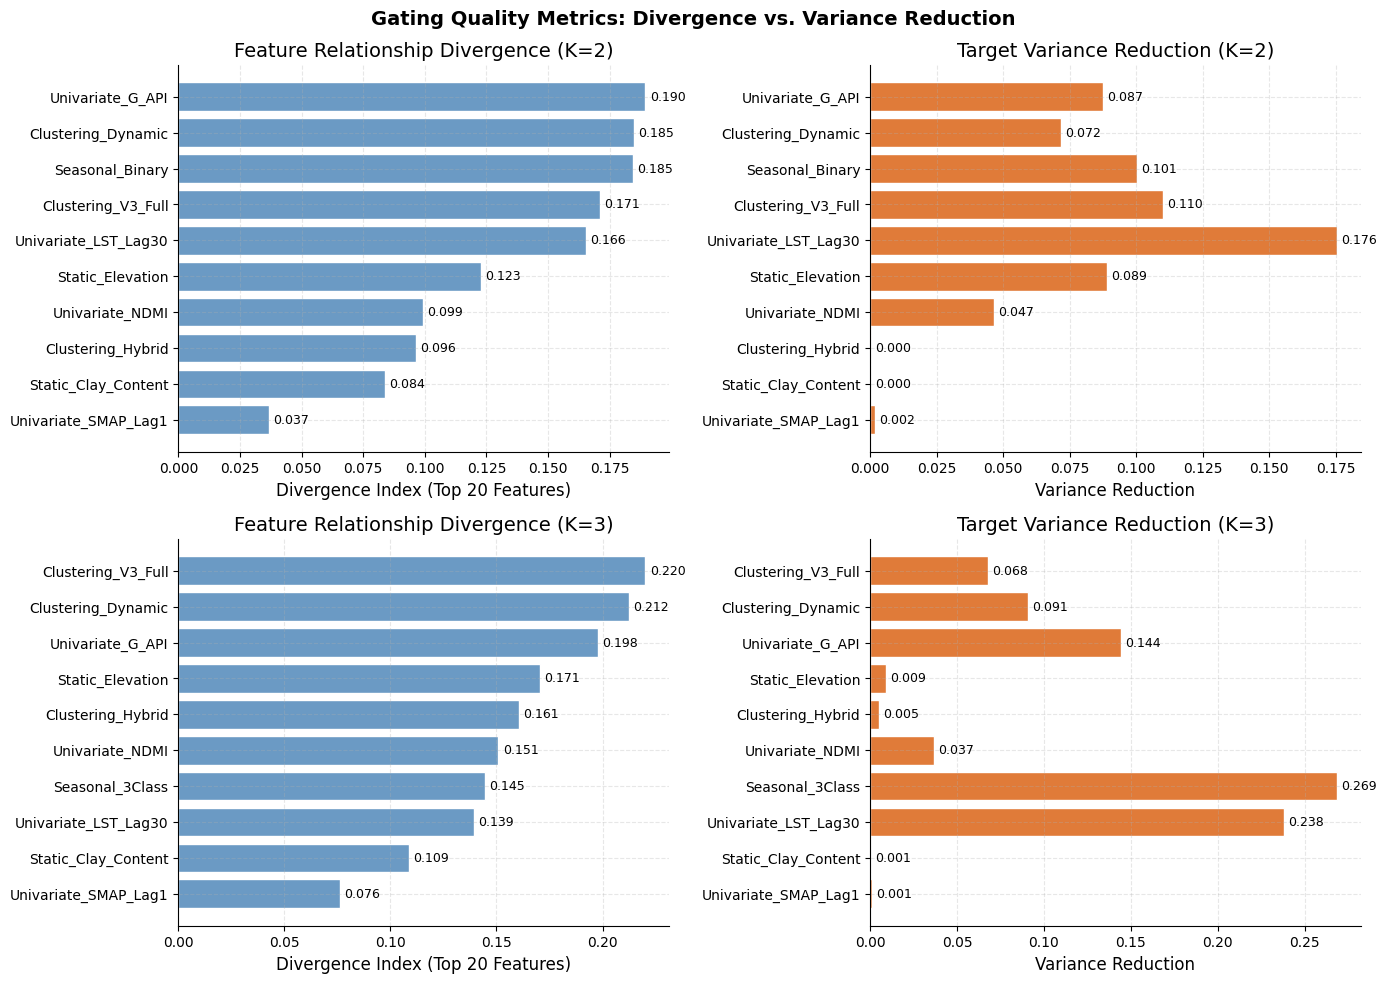

Best Binary Strategy: Univariate_G_API
Best 3-Class Strategy: Clustering_V3_Full


In [8]:
# 1. Compile summary table
df_summary = []
for res in results:
    df_summary.append({
        "Strategy": res["strategy"],
        "K": res["K"],
        "Entropy (Balance)": res["entropy"],
        "Variance Reduction": res["variance_reduction"],
        "Mean KS": res["mean_ks"],
        "Divergence (V3)": res["divergence_v3"],
        "Divergence (Top20)": res["divergence_top20"],
        "Max Drift": res["max_drift"],
        "Drift Feature": res["drift_feature"]
    })

df_summary = pd.DataFrame(df_summary)
print("===== GATING STRATEGIES SUMMARY =====")
display(df_summary.sort_values(by=["K", "Divergence (Top20)"], ascending=[True, False]).round(4))

# Save summary to CSV for referencing in report
df_summary.to_csv("gating_strategies_summary.csv", index=False)

# 2. Plot overall metric comparison
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for i, K in enumerate([2, 3]):
    df_k = df_summary[df_summary["K"] == K].sort_values(by="Divergence (Top20)", ascending=True)
    
    # Left: Divergence
    ax_div = axes[i, 0]
    bars_div = ax_div.barh(df_k["Strategy"], df_k["Divergence (Top20)"], color="#6B9AC4", edgecolor="white")
    ax_div.set_xlabel("Divergence Index (Top 20 Features)")
    ax_div.set_title(f"Feature Relationship Divergence (K={K})")
    ax_div.spines[["top", "right"]].set_visible(False)
    ax_div.bar_label(bars_div, fmt="%.3f", padding=3, fontsize=9)
    
    # Right: Variance Reduction
    ax_vr = axes[i, 1]
    bars_vr = ax_vr.barh(df_k["Strategy"], df_k["Variance Reduction"], color="#E07B39", edgecolor="white")
    ax_vr.set_xlabel("Variance Reduction")
    ax_vr.set_title(f"Target Variance Reduction (K={K})")
    ax_vr.spines[["top", "right"]].set_visible(False)
    ax_vr.bar_label(bars_vr, fmt="%.3f", padding=3, fontsize=9)

plt.suptitle("Gating Quality Metrics: Divergence vs. Variance Reduction", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("gating_quality_metrics_comparison.png", dpi=300)
plt.show()

# 3. Analyze best performers
best_k2_strat = df_summary[df_summary["K"] == 2].sort_values(by="Divergence (Top20)", ascending=False).iloc[0]["Strategy"]
best_k3_strat = df_summary[df_summary["K"] == 3].sort_values(by="Divergence (Top20)", ascending=False).iloc[0]["Strategy"]

print(f"Best Binary Strategy: {best_k2_strat}")
print(f"Best 3-Class Strategy: {best_k3_strat}")

## 8. Diagnostic Visualizations for Best Performing Strategies

We write code to dynamically fetch the labels of the best-performing strategies identified in the previous cell. We then:
1. Plot the target soil moisture distribution overlays across the groups.
2. Plot a correlation drift heatmap showing feature-target relationships within each group for the top 20 globally correlated V3 features. This highlights which features are active in which regime.

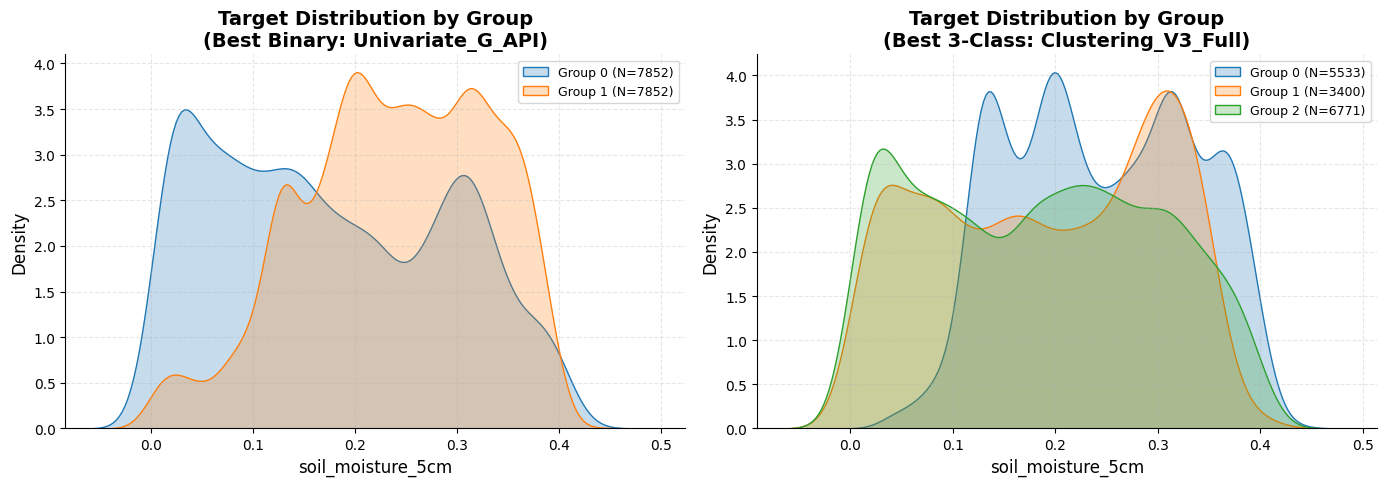

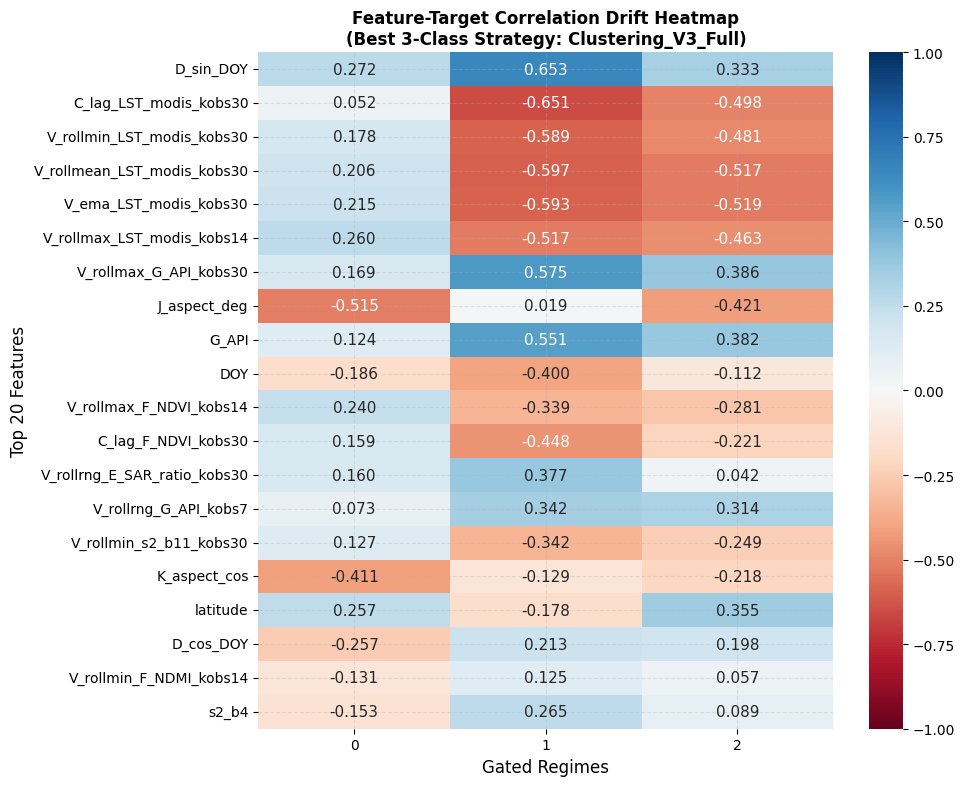

In [9]:
# Helper to retrieve labels dynamically
def get_labels_for_strategy(df, name, K):
    if name.startswith("Univariate_"):
        proxy_name = name.replace("Univariate_", "")
        col = univariate_proxies[proxy_name]
        return quantile_bin(df, col, K)
    elif name == "Seasonal_Binary":
        cond_k2 = [
            df['month'].isin([5, 6, 7, 8, 9, 10]),
            df['month'].isin([11, 12, 1, 2, 3, 4])
        ]
        return np.select(cond_k2, [0, 1], default=0)
    elif name == "Seasonal_3Class":
        cond_k3 = [
            df['month'].isin([7, 8, 9]),
            df['month'].isin([11, 12, 1, 2, 3]),
            df['month'].isin([4, 5, 6, 10])
        ]
        return np.select(cond_k3, [0, 1, 2], default=2)
    elif name.startswith("Static_"):
        proxy_name = name.replace("Static_", "")
        col = static_proxies[proxy_name]
        return quantile_bin(df, col, K)
    elif name == "Clustering_Dynamic":
        X = prepare_clustering_data(df, cols_dyn)
        kmeans = KMeans(n_clusters=K, random_state=42, n_init=10)
        return kmeans.fit_predict(X)
    elif name == "Clustering_Hybrid":
        X = prepare_clustering_data(df, cols_hyb)
        kmeans = KMeans(n_clusters=K, random_state=42, n_init=10)
        return kmeans.fit_predict(X)
    elif name == "Clustering_V3_Full":
        X = prepare_clustering_data(df, features)
        kmeans = KMeans(n_clusters=K, random_state=42, n_init=10)
        return kmeans.fit_predict(X)
    else:
        raise ValueError(f"Unknown strategy {name}")

# Get labels
labels_best_k2 = get_labels_for_strategy(train_df, best_k2_strat, 2)
labels_best_k3 = get_labels_for_strategy(train_df, best_k3_strat, 3)

# 1. Target density plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Binary target distribution
ax2 = axes[0]
for g in sorted(np.unique(labels_best_k2)):
    mask = (labels_best_k2 == g)
    sns.kdeplot(train_df.loc[mask, target_col], ax=ax2, label=f"Group {g} (N={mask.sum()})", fill=True, alpha=0.25)
ax2.set_title(f"Target Distribution by Group\n(Best Binary: {best_k2_strat})", fontweight="bold")
ax2.set_xlabel("soil_moisture_5cm")
ax2.legend(fontsize=9)
ax2.spines[["top", "right"]].set_visible(False)

# 3-Class target distribution
ax3 = axes[1]
for g in sorted(np.unique(labels_best_k3)):
    mask = (labels_best_k3 == g)
    sns.kdeplot(train_df.loc[mask, target_col], ax=ax3, label=f"Group {g} (N={mask.sum()})", fill=True, alpha=0.25)
ax3.set_title(f"Target Distribution by Group\n(Best 3-Class: {best_k3_strat})", fontweight="bold")
ax3.set_xlabel("soil_moisture_5cm")
ax3.legend(fontsize=9)
ax3.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig("best_gating_target_distributions.png", dpi=300)
plt.show()

# 2. Plot correlation drift heatmap for the best K=3 strategy
# Get the top 20 globally correlated V3 features
global_corrs = train_df[features].corrwith(train_df[target_col]).abs().fillna(0)
top_features = global_corrs.sort_values(ascending=False).head(20).index.tolist()

# Find drift details for the best K=3 strategy
best_k3_res = next(res for res in results if res["strategy"] == best_k3_strat and res["K"] == 3)
corr_matrix_best_k3 = best_k3_res["corr_matrix"].loc[top_features]

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_matrix_best_k3, annot=True, fmt=".3f", cmap="RdBu", vmin=-1.0, vmax=1.0, center=0.0, ax=ax)
ax.set_title(f"Feature-Target Correlation Drift Heatmap\n(Best 3-Class Strategy: {best_k3_strat})", fontsize=12, fontweight="bold")
ax.set_xlabel("Gated Regimes")
ax.set_ylabel("Top 20 Features")
plt.tight_layout()
plt.savefig("best_k3_correlation_drift_heatmap.png", dpi=300)
plt.show()